In [36]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('/home/mahaputra971/pt_skp/output/pondok-pitaya_2026_04_15_02_14_37/reviews_most_relevant.csv')

In [38]:
# Tentukan tanggal awal dan akhir
start_date = '2020-12-30'
end_date = '2026-12-30'

# Konversi kolom ke datetime terlebih dahulu
df['review_post_date'] = pd.to_datetime(df['review_post_date'])

# Filter dataframe berdasarkan tanggal
df = df[(df['review_post_date'] >= start_date) & (df['review_post_date'] <= end_date)]

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   username              226 non-null    object        
 1   user_country          226 non-null    object        
 2   room_view             224 non-null    object        
 3   stay_duration         226 non-null    object        
 4   stay_type             226 non-null    object        
 5   review_post_date      226 non-null    datetime64[ns]
 6   review_title          226 non-null    object        
 7   rating                226 non-null    float64       
 8   original_lang         226 non-null    object        
 9   review_text_liked     133 non-null    object        
 10  review_text_disliked  102 non-null    object        
 11  full_review           226 non-null    object        
 12  en_full_review        165 non-null    object        
 13  found_helpful       

In [40]:
df.head()

,username,user_country,room_view,stay_duration,stay_type,review_post_date,review_title,rating,original_lang,review_text_liked,review_text_disliked,full_review,en_full_review,found_helpful,found_unhelpful,owner_resp_text
0,Emily,United Kingdom,One-Bedroom Suite,7 nights,Family,2024-08-25,Exceptional,10.0,en,The staff are fantastic and the food is delici...,NaN,title: Exceptional. liked: The staff are fanta...,title: Exceptional. liked: The staff are fanta...,0,0,NaN
1,Kizzy,Malta,One-Bedroom Suite,2 nights,Family,2026-03-26,My second time there due to location. The most...,7.0,en-us,The location is amazing. Nice grounds also. Ro...,Cleanliness needs to be upgraded. But doable i...,title: My second time there due to location. T...,title: My second time there due to location. T...,0,0,NaN
2,Rob,Australia,Villa 4 Adults,4 nights,Couple,2026-03-07,Relaxing and easy going.,7.0,en,Location.,Needs lots fixed . Broken and old. No security...,title: Relaxing and easy going. liked: Locatio...,title: Relaxing and easy going. liked: Locatio...,0,0,NaN
3,Sabrina,Australia,One-Bedroom Suite,1 night,Group,2026-02-02,Nice and Affordable Stay,8.0,en,Pondok Pitaya is a beachfront hotel. The locat...,"I did not like the bathroom, as it was partial...",title: Nice and Affordable Stay. liked: Pondok...,title: Nice and Affordable Stay. liked: Pondok...,0,0,NaN
4,Mark,Australia,One-Bedroom Suite,6 nights,Family,2025-11-17,Good,7.0,en,"Location right on the beach, asked for a fridg...",Hotel a little run down,title: Good. liked: Location right on the beac...,title: Good. liked: Location right on the beac...,0,0,"Dear Mark Thank you for your review, We will u..."


In [41]:
df.fillna(0, inplace=True)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   username              226 non-null    object        
 1   user_country          226 non-null    object        
 2   room_view             226 non-null    object        
 3   stay_duration         226 non-null    object        
 4   stay_type             226 non-null    object        
 5   review_post_date      226 non-null    datetime64[ns]
 6   review_title          226 non-null    object        
 7   rating                226 non-null    float64       
 8   original_lang         226 non-null    object        
 9   review_text_liked     226 non-null    object        
 10  review_text_disliked  226 non-null    object        
 11  full_review           226 non-null    object        
 12  en_full_review        226 non-null    object        
 13  found_helpful       

In [43]:
df.head()

,username,user_country,room_view,stay_duration,stay_type,review_post_date,review_title,rating,original_lang,review_text_liked,review_text_disliked,full_review,en_full_review,found_helpful,found_unhelpful,owner_resp_text
0,Emily,United Kingdom,One-Bedroom Suite,7 nights,Family,2024-08-25,Exceptional,10.0,en,The staff are fantastic and the food is delici...,0,title: Exceptional. liked: The staff are fanta...,title: Exceptional. liked: The staff are fanta...,0,0,0
1,Kizzy,Malta,One-Bedroom Suite,2 nights,Family,2026-03-26,My second time there due to location. The most...,7.0,en-us,The location is amazing. Nice grounds also. Ro...,Cleanliness needs to be upgraded. But doable i...,title: My second time there due to location. T...,title: My second time there due to location. T...,0,0,0
2,Rob,Australia,Villa 4 Adults,4 nights,Couple,2026-03-07,Relaxing and easy going.,7.0,en,Location.,Needs lots fixed . Broken and old. No security...,title: Relaxing and easy going. liked: Locatio...,title: Relaxing and easy going. liked: Locatio...,0,0,0
3,Sabrina,Australia,One-Bedroom Suite,1 night,Group,2026-02-02,Nice and Affordable Stay,8.0,en,Pondok Pitaya is a beachfront hotel. The locat...,"I did not like the bathroom, as it was partial...",title: Nice and Affordable Stay. liked: Pondok...,title: Nice and Affordable Stay. liked: Pondok...,0,0,0
4,Mark,Australia,One-Bedroom Suite,6 nights,Family,2025-11-17,Good,7.0,en,"Location right on the beach, asked for a fridg...",Hotel a little run down,title: Good. liked: Location right on the beac...,title: Good. liked: Location right on the beac...,0,0,"Dear Mark Thank you for your review, We will u..."


In [44]:
def plot_barplot(data, x_col, y_col, title="", format_number="", x_label="", y_label="", colour_bar_set="3"):
    plt.figure(figsize=(10, max(6, len(data) * 0.4))) # Tinggi otomatis menyesuaikan banyaknya negara

    # --- 1. DETEKSI OTOMATIS: VERTIKAL ATAU HORIZONTAL? ---
    # Jika Y-nya angka, berarti Vertikal. Jika Y-nya teks, berarti Horizontal.
    if pd.api.types.is_numeric_dtype(data[y_col]):
        orientation = 'vertical'
        color_basis = data[y_col] # Warna ikut tinggi Y
    else:
        orientation = 'horizontal'
        color_basis = data[x_col] # Warna ikut panjang X (Jumlah)

    # --- 2. LOGIKA WARNA ---
    if colour_bar_set == "1": # Tinggi=Hijau
        norm = plt.Normalize(color_basis.min(), color_basis.max())
        sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
        colors = [sm.to_rgba(val) for val in color_basis]
    elif colour_bar_set == "2": # Tinggi=Merah
        norm = plt.Normalize(color_basis.min(), color_basis.max())
        sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=norm)
        colors = [sm.to_rgba(val) for val in color_basis]
    else: # Mode 3 (Default Biru - Aman untuk Kategori)
        colors = ["#4c72b0"] * len(data)
        sm = None

    # --- 3. MEMBUAT PLOT ---
    barplot = sns.barplot(
        x=x_col, 
        y=y_col,
        data=data,
        palette=colors,
        hue=y_col if orientation == 'horizontal' else x_col, # Fix warning seaborn baru
        legend=False
    )

    # --- 4. MEMBERI LABEL ANGKA (SMART POSITIONING) ---
    for bar in barplot.patches:
        # Ambil dimensi batang
        width = bar.get_width()
        height = bar.get_height()
        
        # Tentukan nilai yang akan ditulis
        value = width if orientation == 'horizontal' else height
        if np.isnan(value): continue

        # Format label
        if isinstance(value, float):
            label_text = f"{format_number}{value:.2f}"
            if value.is_integer(): label_text = f"{format_number}{int(value)}"
        else:
            label_text = f"{format_number}{int(value)}"

        # Tentukan posisi teks
        if orientation == 'horizontal':
            # Jika horizontal, teks ditaruh di sebelah kanan ujung batang
            text_x = width + (data[x_col].max() * 0.01) # Beri sedikit jarak
            text_y = bar.get_y() + height / 2
            ha_align = 'left'
            color_text = 'black' # Teks hitam biar terbaca di background putih
        else:
            # Jika vertikal, teks ditaruh di tengah/atas batang
            text_x = bar.get_x() + width / 2
            text_y = bar.get_y() + height / 2
            ha_align = 'center'
            color_text = 'white'

        plt.text(
            text_x, 
            text_y, 
            label_text, 
            va='center', 
            ha=ha_align, 
            fontsize=10, 
            color=color_text, 
            weight='bold'
        )

    # Kosmetik
    plt.title(title, loc="center", fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(x_label if x_label else x_col, fontsize=12)
    plt.ylabel(y_label if y_label else y_col, fontsize=12)
    
    if orientation == 'vertical':
        plt.grid(axis='y', linestyle='--', alpha=0.3)
    else:
        plt.grid(axis='x', linestyle='--', alpha=0.3) # Grid X untuk horizontal

    plt.tight_layout()
    plt.show()

## 1. Rating User

   rating  jumlah
7     8.0      63
9    10.0      54
8     9.0      49
6     7.0      33
5     6.0      10
4     5.0       6
2     3.0       5
0     1.0       3
3     4.0       2
1     2.0       1


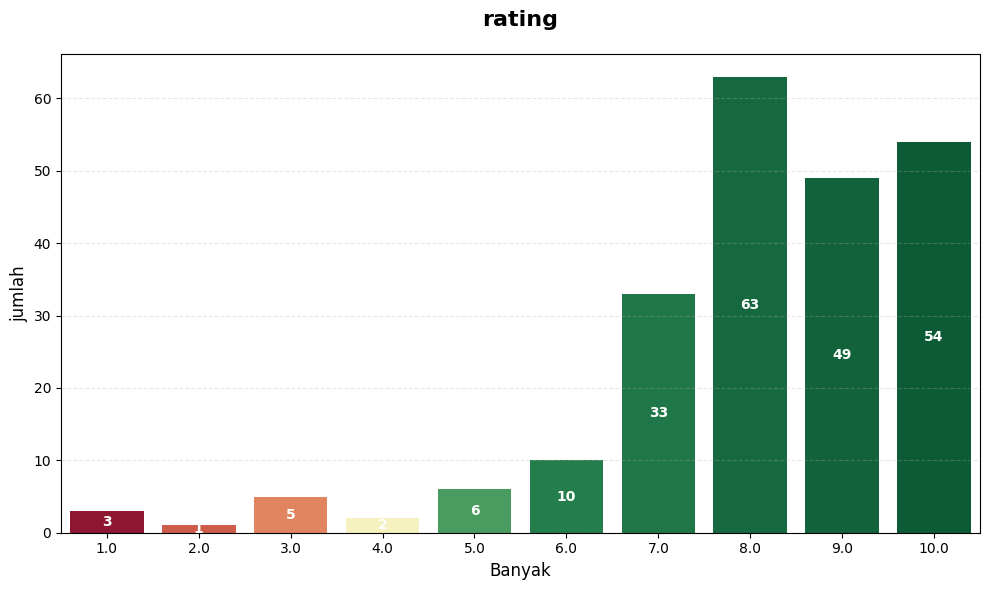

In [45]:
''' 
Membuat sort list dan visualisasi banyak orang tiap rating
'''
count_gender = df.groupby('rating').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(count_gender)  
plot_barplot(
    data=count_gender,
    x_col="rating",
    y_col="jumlah", 
    title="rating",
    format_number="",
    x_label="Banyak",
    colour_bar_set="2"
)

In [46]:
dislike_df = df[df['review_text_disliked'] != 0]
dislike_list = dislike_df['review_text_disliked'].tolist()

print(f"Total komentar dislike: {len(dislike_list)}")
print(f"Komentar dislike: {dislike_list}")

Total komentar dislike: 102
Komentar dislike: ['Cleanliness needs to be upgraded. But doable if you’re not too fussy.', 'Needs lots fixed . Broken and old. No security for single women etc at night. Staff seem a bit complacent to walk past empty bottles and plates at villa . Should be cleaning up at all times. Dogs are not always wanted around while eating etc.', 'I did not like the bathroom, as it was partially open. I understand that this is a Bali-style design with no windows; however, the bathroom does not stay clean for long, and bugs and insects are always present. It is very annoying to have to keep the bathroom door closed at all times to prevent insects and mosquitoes from entering the room. There was a large window above the door connecting to the bathroom, and it only had a regular curtain. In my opinion, a blackout curtain would help keep the room darker in the morning.', 'Hotel a little run down', 'Small fridge in room would be good', 'Nothing, it could do with a strong wa

In [47]:
like_df = df[df['review_text_liked'] != 0]
like_list = like_df['review_text_liked'].tolist()

print(f"Total komentar like: {len(like_list)}")
print(f"Komentar like: {like_list}")

Total komentar like: 133
Komentar like: ['The staff are fantastic and the food is delicious. Ideal surf spot and hidden away gem to get a real local feel.', 'The location is amazing. Nice grounds also. Rooms have nice decent decor. Beds are comfortable', 'Location.', "Pondok Pitaya is a beachfront hotel. The location is great as you walk through the hotel's garden and arrive at the beach. The room was clean and comfortable, which met the needs for one night.", 'Location right on the beach, asked for a fridge and they brought us one within an hour', 'Amazing location good facilities And great staff', 'The property is on the beach and is large. It has everything you need. I liked the massage here, better than the other one in the street, and the views of the surf. We were watching the surfers all the time and my hubby had a great time surfing. Also loved Nikki’s yoga classes up the road, strong but fantastic too. We had a relaxing stay overall.', 'Our stay at Pondok Pitaya Balian Hotel w

## 2. User's Country

            user_country  jumlah
1              Australia     108
18           New Zealand      13
8                 France      12
9                Germany      12
33         United States       9
32        United Kingdom       9
12             Indonesia       8
29           Switzerland       8
16           Netherlands       7
13                 Italy       5
14                 Japan       4
27                 Spain       3
28                Sweden       3
22              Portugal       2
7                Finland       2
6                Denmark       2
24                Russia       2
26          South Africa       1
30                Taiwan       1
31  United Arab Emirates       1
25              Slovenia       1
23               Reunion       1
0              Argentina       1
21                Poland       1
20                  Peru       1
19      Papua New Guinea       1
15                 Malta       1
11                 India       1
10             Hong Kong       1
5         

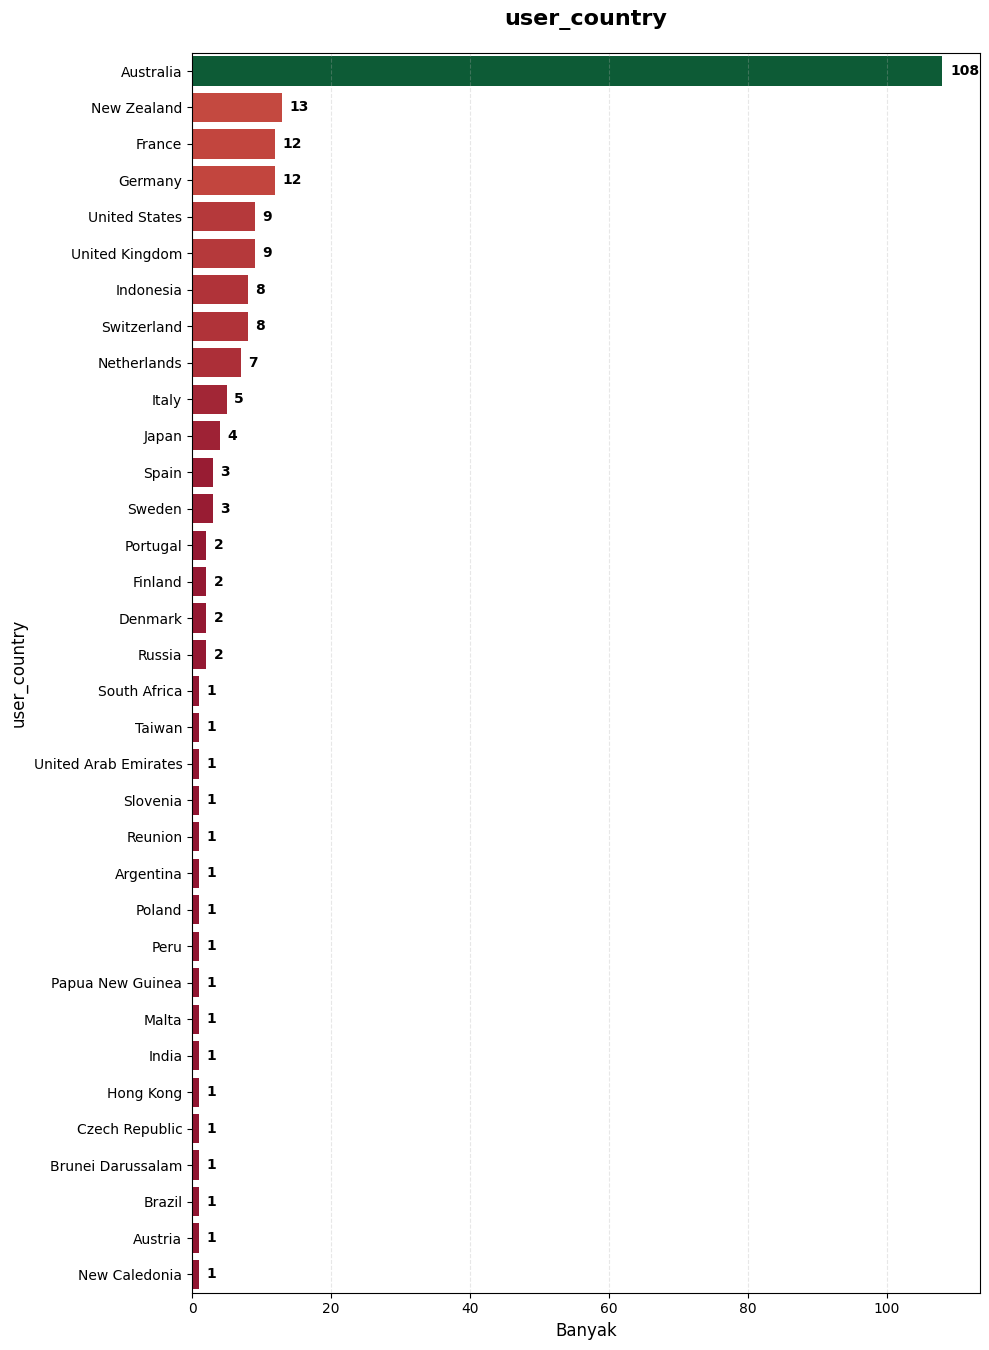

In [48]:
''' 
Membuat sort list dan visualisasi banyak orang tiap user_country
'''
count_gender = df.groupby('user_country').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(count_gender)  
plot_barplot(
    data=count_gender,
    x_col="jumlah",
    y_col="user_country", 
    title="user_country",
    format_number="",
    x_label="Banyak",
    colour_bar_set="1"
)

## 3. Owner Respone

In [49]:
owner_df = df[df['owner_resp_text'] != 0]
owner_df = owner_df['owner_resp_text'].tolist()

print(f"Total komentar owner_resp_text: {len(owner_df)}")
print(f"Komentar owner_resp_text: {owner_df}")

Total komentar owner_resp_text: 6
Komentar owner_resp_text: ['Dear Mark Thank you for your review, We will use them to improve our service Best Regards, Pondok Pitaya', "Dear Kim Thank you for your review We're glad you had decent experience and we appreciate your suggestions we will use them to improve our service Best Regards, Pondok Pitaya", "Dear Karen Thank you so much for your kind review we're happy to hear that a great experience with us. we look forward to welcoming you again Best regards, Pondok Pitaya", "Dear Heidi Thank you for your kind review. we're happy to hear that a great experience with us. we look forward to welcoming you again Best Regards, Pondok Pitaya", "Dear Delia Almeida, Thank you so much for your kind review and for staying with us. we're very happy to hear that you enjoyed our location, cleanliness, and our staff friendly. We truly appreciate your feedback regarding the bathroom and we will work on improving the maintenance to ensure a better experience for

## 4. Room View

                          room_view  jumlah
1                 One-Bedroom Suite     170
2  Standard Twin Room with Sea View      21
5                    Villa 4 Adults      14
3                 Two-Bedroom Villa      11
4      Two-Bedroom Villa (6 Adults)       8
0                                 0       2


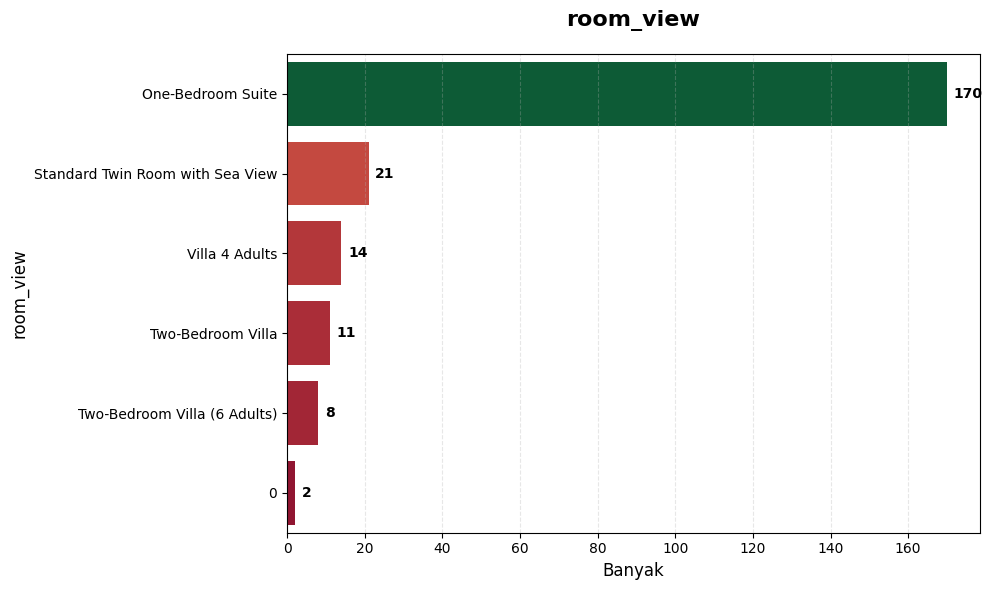

In [50]:
''' 
Membuat sort list dan visualisasi banyak orang tiap room_view
'''
count_gender = df.groupby('room_view').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(count_gender)  
plot_barplot(
    data=count_gender,
    x_col="jumlah",
    y_col="room_view", 
    title="room_view",
    format_number="",
    x_label="Banyak",
    colour_bar_set="1"
)

## 5. Stay Duration

   stay_duration  jumlah
8       3 nights      54
6       2 nights      49
0        1 night      36
9       4 nights      36
10      5 nights      13
11      6 nights      12
12      7 nights       9
13      8 nights       4
14      9 nights       4
1      10 nights       2
2      11 nights       2
4      14 nights       2
3      13 nights       1
5      16 nights       1
7      27 nights       1


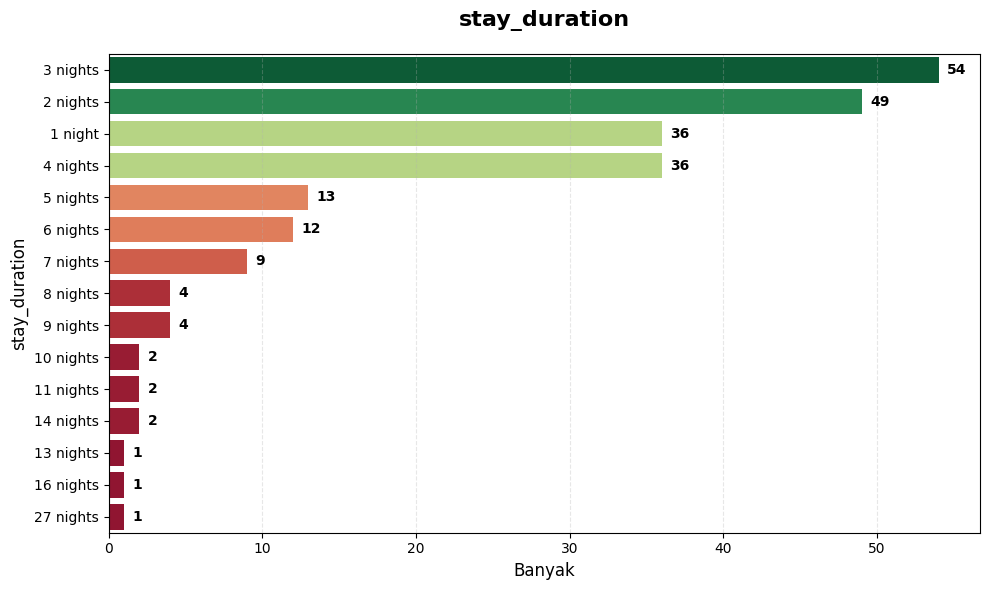

In [51]:
''' 
Membuat sort list dan visualisasi banyak orang tiap stay_duration
'''
count_gender = df.groupby('stay_duration').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(count_gender)  
plot_barplot(
    data=count_gender,
    x_col="jumlah",
    y_col="stay_duration", 
    title="stay_duration",
    format_number="",
    x_label="Banyak",
    colour_bar_set="1"
)

## 6. Stay Type

        stay_type  jumlah
0          Couple     106
1          Family      49
3  Solo traveller      43
2           Group      28


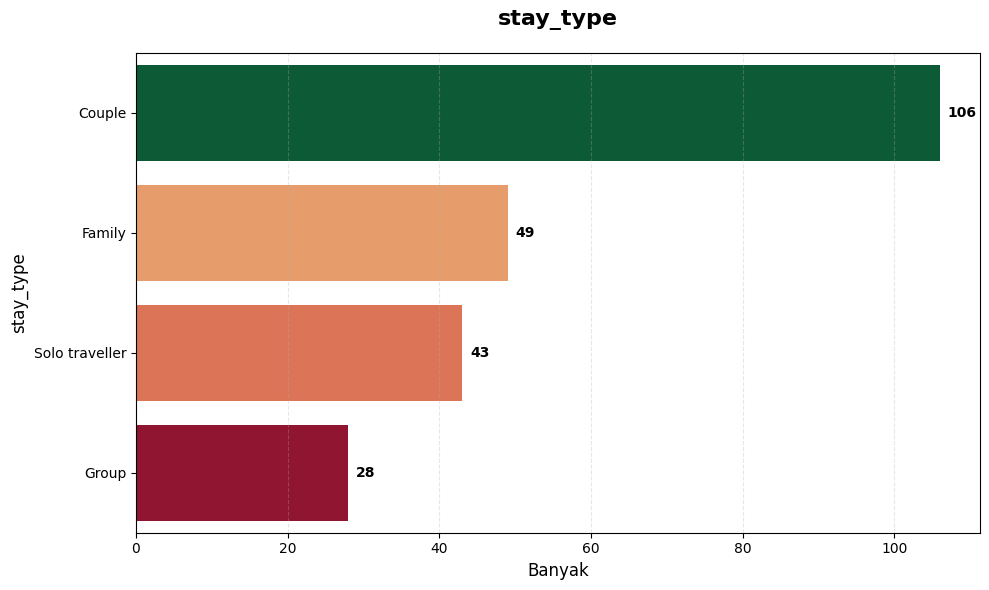

In [52]:
''' 
Membuat sort list dan visualisasi banyak orang tiap stay_type
'''
stay_type = df.groupby('stay_type').size().reset_index(name='jumlah').sort_values(by='jumlah', ascending=False)
print(stay_type)  
plot_barplot(
    data=stay_type,
    x_col="jumlah",
    y_col="stay_type", 
    title="stay_type",
    format_number="",
    x_label="Banyak",
    colour_bar_set="1"
)

## 7. Tahun Review

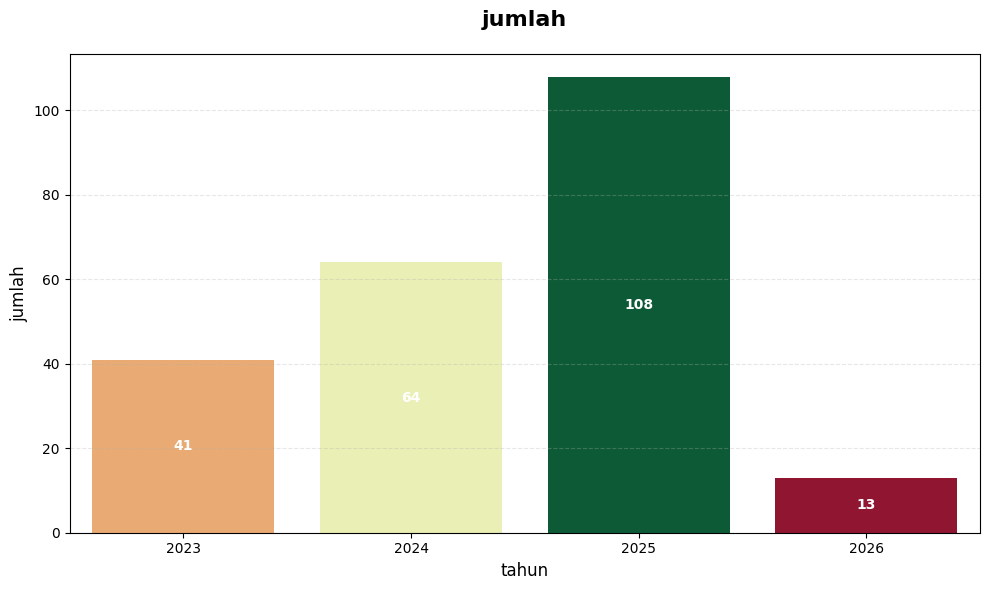

,tahun,jumlah
0,2023,41
1,2024,64
2,2025,108
3,2026,13


In [53]:
# --- 1. DATA PREPARATION ---

# Pastikan kolom tanggal bertipe datetime
# Jika format tanggalmu beda (misal: "12 Dec 2023"), pandas biasanya otomatis mengenali
df['review_post_date'] = pd.to_datetime(df['review_post_date'])

# Ekstrak tahun ke kolom baru
df['year'] = df['review_post_date'].dt.year

# Hitung jumlah review per tahun dan URUTKAN BERDASARKAN TAHUN (sort_index)
# Kita pakai sort_index() agar tahunnya urut (2020, 2021, 2022...), bukan acak.
year_counts = df['year'].value_counts().sort_index()

# Konversi ke DataFrame agar mudah di-plot seaborn
year_df = year_counts.reset_index()
year_df.columns = ['tahun', 'jumlah']

# --- 2. VISUALISASI (Best Practice) ---

# plt.figure(figsize=(10, 6))

# Gunakan satu warna (misal: biru) karena ini data waktu, tidak perlu warna-warni 
# kecuali Anda ingin menghighlight tahun tertentu.
plot_barplot(
    data=year_df,
    x_col="tahun",
    y_col="jumlah", 
    title="jumlah",
    format_number="",
    x_label="tahun",
    colour_bar_set="1"
)
year_df

   Year    rating
0  2023  8.585366
1  2024  8.656250
2  2025  7.657407
3  2026  7.769231


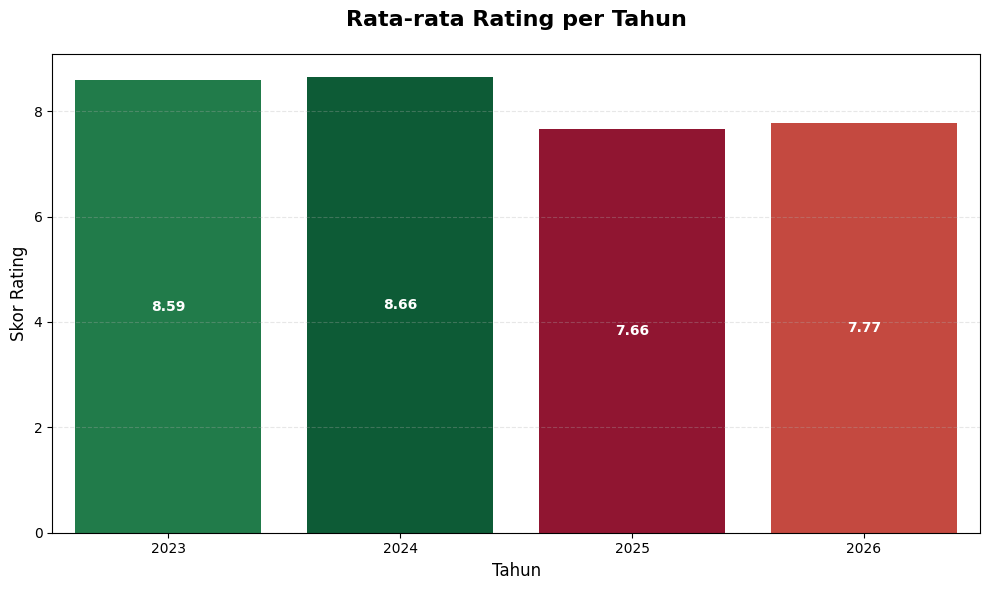

In [54]:
df['review_post_date'] = pd.to_datetime(df['review_post_date'])
df['Year'] = df['review_post_date'].dt.year

# Reset index agar 'Year' kembali menjadi kolom
rating_year = df.groupby('Year')['rating'].mean().reset_index()

# Opsional: Urutkan tahun biar rapi
rating_year = rating_year.sort_values('Year')

print(rating_year)

# --- CARA PENGGUNAAN ---
plot_barplot(
    data=rating_year, 
    x_col="Year", 
    y_col="rating", 
    title="Rata-rata Rating per Tahun", 
    x_label="Tahun",
    y_label="Skor Rating",
    colour_bar_set="1" # Gunakan 3 (Biru) untuk data tahunan agar netral
)

In [55]:
# Filter dulu: Ambil hanya data yang 'review_text_disliked' BUKAN 0
filtered_df = df[df['review_text_disliked'] != 0]

# Baru di-grouping
dislike_by_year = filtered_df.groupby('Year')['review_text_disliked'].apply(list)

# --- CARA MENGAKSES HASILNYA (Sama seperti kodemu) ---
print("=== Statistik Dislike per Tahun ===")
for year, comments in dislike_by_year.items():
    print(f"Tahun {year}: Ditemukan {len(comments)} komentar dislike.")
    print(f"{comments}") 
    print("-" * 30)

=== Statistik Dislike per Tahun ===
Tahun 2023: Ditemukan 15 komentar dislike.
['Not the fault of the hotel, but after a big rain, the water quality for surfing got really bad. We had to stay out of the water for two days.', 'No fridge mirror in bathroom to high vanity tap to high slashing water everywhere', 'Dogs barking', 'Mattress a bit hard and only 2 small pillows. Rooms decent but needing some maintenance.', 'Shame the sea was so dirty', 'No tea or coffee or cups provided in the villa', 'I stayed in C3 which was super clean but quite small and dark. I know it was high season but to be honest I think it was expensive at more than $100AUD per night. I think it would also be ok to eliminate smoking from restaurant🙏', 'Rooms are very dark, and walls are paper thin.', 'very small rooms', 'First world problem… the water got cold very quickly.', 'the bathrooms', "A major issue here for our family and many others which we spoke to there was the staff lacking in communication and service,

In [56]:
# Filter dulu: Ambil hanya data yang 'review_text_disliked' BUKAN 0
filtered_df = df[df['review_text_liked'] != 0].copy()

# Baru di-grouping
dislike_by_year = filtered_df.groupby('Year')['review_text_liked'].apply(list)

# --- CARA MENGAKSES HASILNYA (Sama seperti kodemu) ---
print("=== Statistik like per Tahun ===")
for year, comments in dislike_by_year.items():
    print(f"Tahun {year}: Ditemukan {len(comments)} komentar like.")
    print(f"{comments}") 
    print("-" * 30)

=== Statistik like per Tahun ===
Tahun 2023: Ditemukan 20 komentar like.
['Great location, attentive staff and unique decor. This was one of our favorite places to stay on Bali. We had massages from Ria that were AMAZING. Food was better than expected and a great value. Good air conditioning and clean rooms.', "Amazing location, above what we expected. Value for money wise, this place is top notch. If you've been to the kommune, it's like a poor mans version of that", 'Breakfast was very good excellent location', 'Close to the surf', 'Great location at surf beach. Good restaurant and lovely staff. Best massage service out of our stay :)', 'Amazing location on Balian Beach. Surf was amazing & right at the door.', 'Fantastic hospital staff', 'Location and surf', 'Large villa with beautiful view of the ocean. Friendly staff.', 'I’ve stayed before as the beach front location is unbeatable. The Healthy Breakfast included was fresh clean and delicious. The yoga with Valentina was fantastic a

                          room_view    rating
4                    Villa 4 Adults  5.875000
2                 Two-Bedroom Villa  7.571429
0                 One-Bedroom Suite  7.930000
1  Standard Twin Room with Sea View  8.000000
3      Two-Bedroom Villa (6 Adults)  8.200000


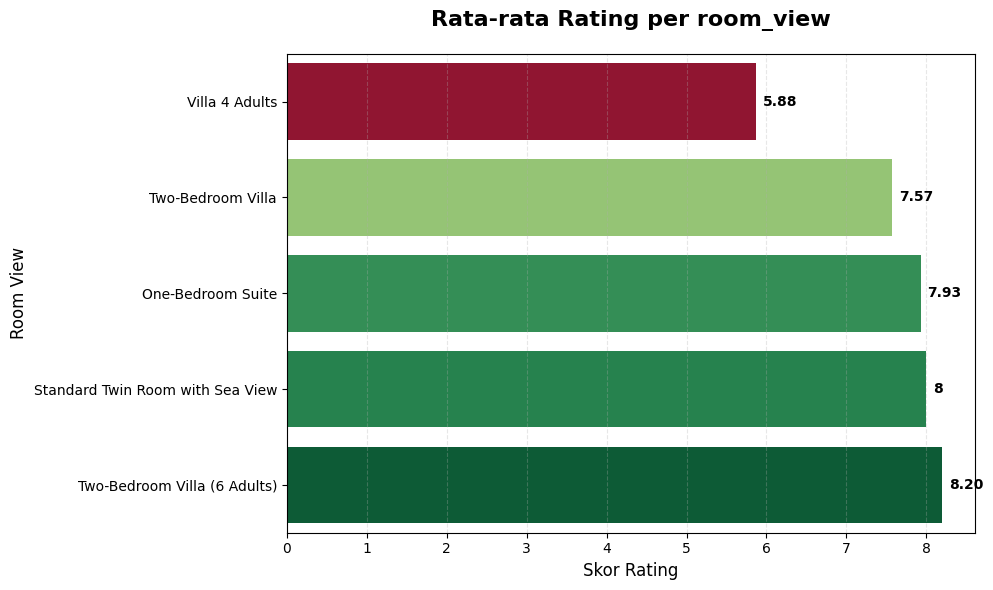

In [57]:
# Reset index agar 'Year' kembali menjadi kolom
rating_room_year = filtered_df.groupby('room_view')['rating'].mean().reset_index()

rating_room_year = rating_room_year[rating_room_year!= 0]

# Opsional: Urutkan tahun biar rapi
rating_room_year = rating_room_year.sort_values('rating')

print(rating_room_year)

# --- CARA PENGGUNAAN ---
plot_barplot(
    data=rating_room_year , 
    x_col="rating", 
    y_col="room_view", 
    title="Rata-rata Rating per room_view", 
    x_label="Skor Rating",
    y_label="Room View",
    colour_bar_set="1" # Gunakan 3 (Biru) untuk data tahunan agar netral
)

                          room_view  rating
3      Two-Bedroom Villa (6 Adults)       5
2                 Two-Bedroom Villa       7
4                    Villa 4 Adults       8
1  Standard Twin Room with Sea View      13
0                 One-Bedroom Suite     100


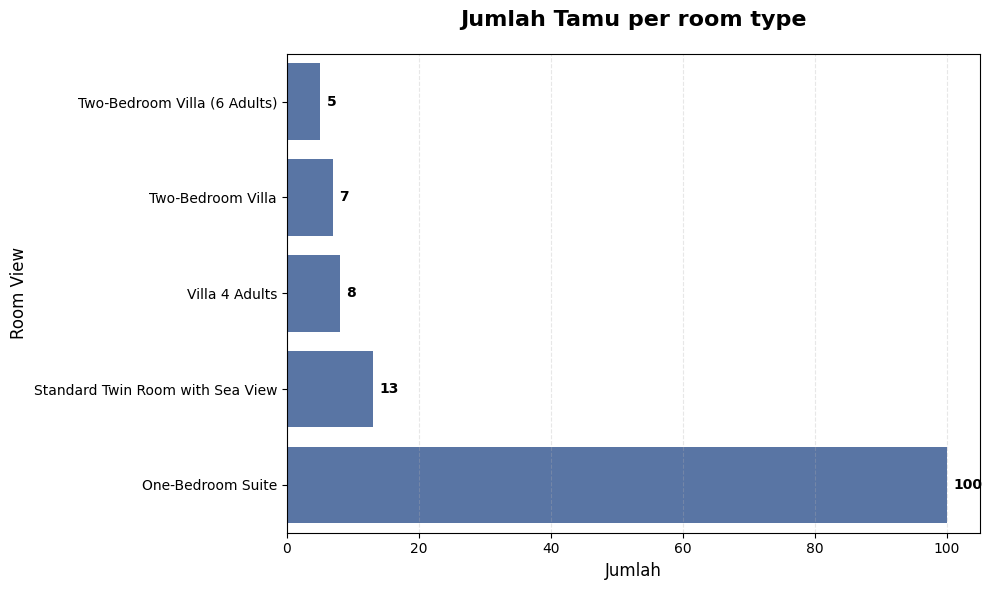

In [58]:
# Reset index agar 'Year' kembali menjadi kolom
rating_room_year = filtered_df.groupby('room_view')['rating'].count().reset_index()

# rating_room_year = rating_room_year[rating_room_year!= 0]

# Opsional: Urutkan tahun biar rapi
rating_room_year = rating_room_year.sort_values('rating')

print(rating_room_year)

# --- CARA PENGGUNAAN ---
plot_barplot(
    data=rating_room_year , 
    x_col="rating", 
    y_col="room_view", 
    title="Jumlah Tamu per room type", 
    x_label="Jumlah",
    y_label="Room View",
    colour_bar_set="3" # Gunakan 3 (Biru) untuk data tahunan agar netral
)

In [59]:
filtered_df = df[df['review_text_disliked'] != 0].copy()
# Baru di-grouping
dislike_by_room_view = filtered_df.groupby('room_view')['review_text_disliked'].apply(list)

# --- CARA MENGAKSES HASILNYA (Sama seperti kodemu) ---
print("=== Statistik Dislike per Kamar ===")
for room_view, comments in dislike_by_room_view.items():
    print(f"Pada {room_view}: Ditemukan {len(comments)} komentar dislike.")
    print(f"{comments}") 
    print("-" * 30)

=== Statistik Dislike per Kamar ===
Pada One-Bedroom Suite: Ditemukan 75 komentar dislike.
['Cleanliness needs to be upgraded. But doable if you’re not too fussy.', 'I did not like the bathroom, as it was partially open. I understand that this is a Bali-style design with no windows; however, the bathroom does not stay clean for long, and bugs and insects are always present. It is very annoying to have to keep the bathroom door closed at all times to prevent insects and mosquitoes from entering the room. There was a large window above the door connecting to the bathroom, and it only had a regular curtain. In my opinion, a blackout curtain would help keep the room darker in the morning.', 'Hotel a little run down', 'Nothing, it could do with a strong water pressure over all the outdoor paths and stones to bring it back that’s all. It was all lovely. Great breakfast included too!', 'Would have been nice to have fruit included in breakfast as I don’t eat ebggs', 'I had an overnight stay an

<Axes: xlabel='review_post_date', ylabel='rating'>

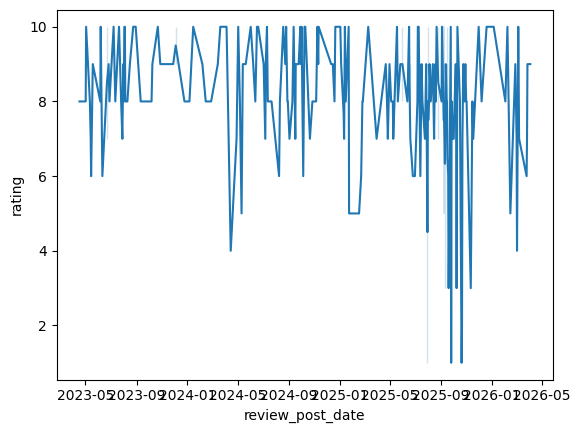

In [60]:
df['review_post_date'] = pd.to_datetime(df['review_post_date'])
sns.lineplot(data=df, x='review_post_date', y='rating')

/tmp/ipykernel_47491/658173592.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.set_index(date_col).resample('M').size()


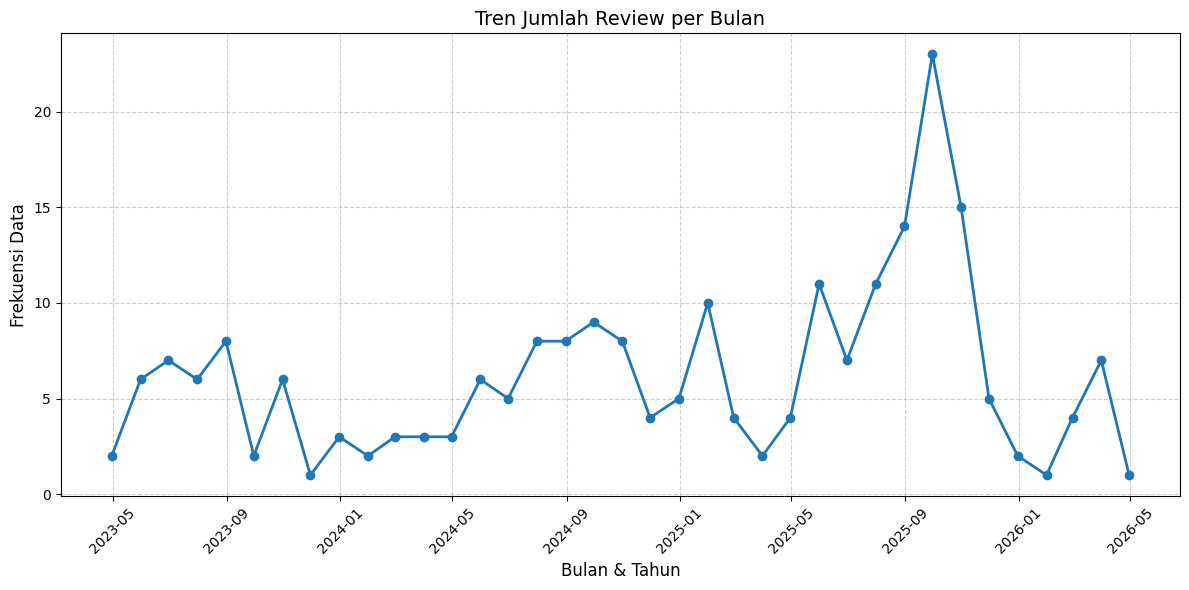

review_post_date
2025-09-30    23
2025-10-31    15
2025-08-31    14
2025-07-31    11
2025-05-31    11
2025-01-31    10
2024-09-30     9
2024-08-31     8
2024-10-31     8
2024-07-31     8
2023-08-31     8
2023-06-30     7
2025-06-30     7
2026-03-31     7
2023-07-31     6
2024-05-31     6
2023-10-31     6
2023-05-31     6
2025-11-30     5
2024-06-30     5
2024-12-31     5
2025-04-30     4
2024-11-30     4
2025-02-28     4
2026-02-28     4
2024-02-29     3
2023-12-31     3
2024-04-30     3
2024-03-31     3
2025-12-31     2
2023-04-30     2
2025-03-31     2
2024-01-31     2
2023-09-30     2
2026-01-31     1
2023-11-30     1
2026-04-30     1
dtype: int64

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan kolom tanggal dikenali sebagai datetime
date_col = 'review_post_date' 
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# 2. Resample data per Bulan (M) dan hitung jumlahnya (.size())
# Kita set tanggal sebagai index dulu agar bisa di-resample
monthly_counts = df.set_index(date_col).resample('M').size()

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linestyle='-', color='#1f77b4', linewidth=2)

# Mempercantik tampilan
plt.title(f'Tren Jumlah Review per Bulan', fontsize=14)
plt.xlabel('Bulan & Tahun', fontsize=12)
plt.ylabel('Frekuensi Data', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Tampilkan
plt.show()
monthly_counts.sort_values(ascending=False)

--- Total Data Per Bulan (Akumulasi Semua Tahun) ---
review_post_date
September    34
August       30
October      29
July         25
May          23
June         19
January      13
March        12
February     11
April        10
November     10
December     10
Name: count, dtype: int64


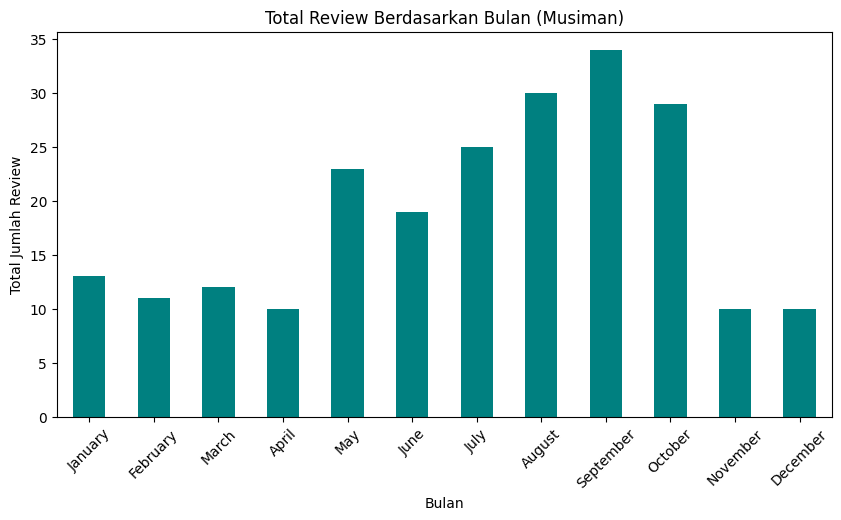

In [62]:
import pandas as pd

# 1. Pastikan kolom target sudah format datetime
col_name = 'review_post_date'  # Sesuaikan nama kolom tanggal Anda
df[col_name] = pd.to_datetime(df[col_name], errors='coerce')

# 2. Urutan bulan yang benar (agar tidak terurut abjad April duluan)
bulan_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# 3. Ambil nama bulan dan hitung
# dt.month_name() mengambil nama bulan (Jan, Feb, dst) mengabaikan tahun
monthly_counts = df[col_name].dt.month_name().value_counts()

# 4. Urutkan hasil sesuai kalender (bukan jumlah terbanyak)
monthly_counts = monthly_counts.reindex(bulan_order, fill_value=0)

# 5. Tampilkan Hasil
print("--- Total Data Per Bulan (Akumulasi Semua Tahun) ---")
print(monthly_counts.sort_values(ascending=False))

# --- Opsional: Tampilkan dalam Grafik Batang ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
monthly_counts.plot(kind='bar', color='teal')
plt.title('Total Review Berdasarkan Bulan (Musiman)')
plt.xlabel('Bulan')
plt.ylabel('Total Jumlah Review')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_47491/658173592.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_counts = df.set_index(date_col).resample('M').size()


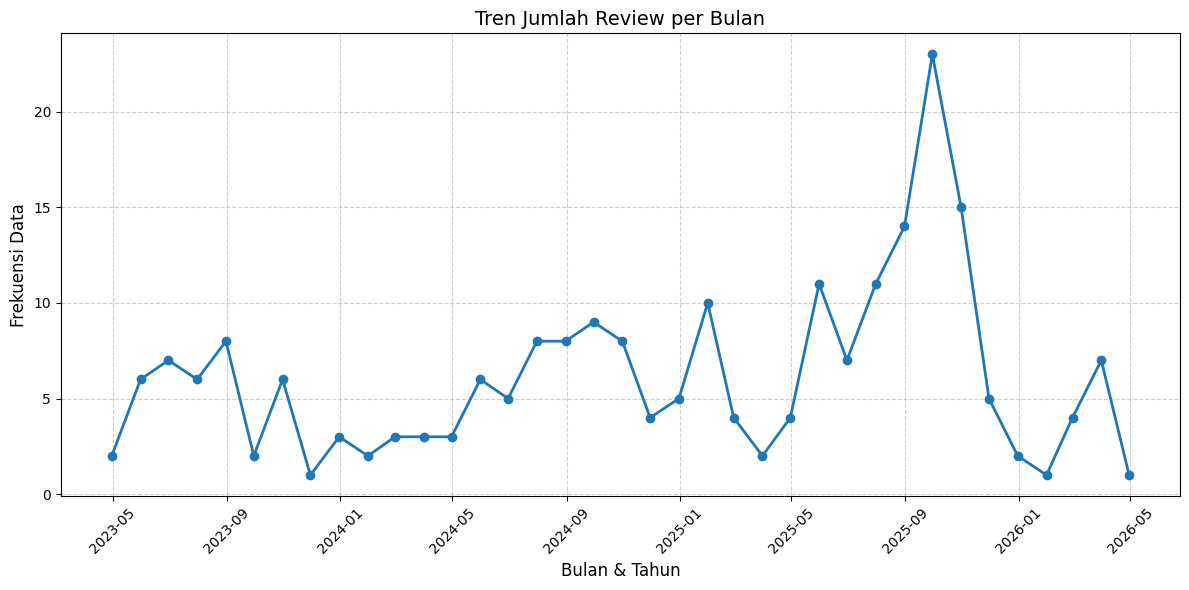

review_post_date
2025-09-30    23
2025-10-31    15
2025-08-31    14
2025-07-31    11
2025-05-31    11
2025-01-31    10
2024-09-30     9
2024-08-31     8
2024-10-31     8
2024-07-31     8
2023-08-31     8
2023-06-30     7
2025-06-30     7
2026-03-31     7
2023-07-31     6
2024-05-31     6
2023-10-31     6
2023-05-31     6
2025-11-30     5
2024-06-30     5
2024-12-31     5
2025-04-30     4
2024-11-30     4
2025-02-28     4
2026-02-28     4
2024-02-29     3
2023-12-31     3
2024-04-30     3
2024-03-31     3
2025-12-31     2
2023-04-30     2
2025-03-31     2
2024-01-31     2
2023-09-30     2
2026-01-31     1
2023-11-30     1
2026-04-30     1
dtype: int64

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Pastikan kolom tanggal dikenali sebagai datetime
date_col = 'review_post_date' 
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

# 2. Resample data per Bulan (M) dan hitung jumlahnya (.size())
# Kita set tanggal sebagai index dulu agar bisa di-resample
monthly_counts = df.set_index(date_col).resample('M').size()

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_counts.index, monthly_counts.values, marker='o', linestyle='-', color='#1f77b4', linewidth=2)

# Mempercantik tampilan
plt.title(f'Tren Jumlah Review per Bulan', fontsize=14)
plt.xlabel('Bulan & Tahun', fontsize=12)
plt.ylabel('Frekuensi Data', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Tampilkan
plt.show()
monthly_counts.sort_values(ascending=False)

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_multivariate_barplot(df, x_col, hue_col, title="", x_label="", y_label="Jumlah", top_n_hue=5, palette="tab20"):
    """
    Fungsi template Grouped Bar Chart + Garis Tren (MAXIMUM CONTRAST).
    Dengan warna berlawanan, garis tebal, dan marker besar untuk visual impact tinggi.
    """
    # --- 1. DATA PREPARATION ---
    data_grouped = df.groupby([x_col, hue_col]).size().reset_index(name='counts')

    # --- 2. FILTER TOP N ---
    top_categories = df[hue_col].value_counts().nlargest(top_n_hue).index.tolist()
    
    # [PENTING] Agar garis tidak terputus, kita buat dataframe lengkap untuk semua kombinasi X dan Hue
    all_x = sorted(df[x_col].unique().astype(str))
    mux = pd.MultiIndex.from_product([all_x, top_categories], names=[x_col, hue_col])
    
    data_filtered = data_grouped[data_grouped[hue_col].isin(top_categories)].copy()
    data_filtered[x_col] = data_filtered[x_col].astype(str)
    
    # Gabungkan dengan template lengkap agar data yang kosong terisi 0
    data_filtered = data_filtered.set_index([x_col, hue_col]).reindex(mux, fill_value=0).reset_index()

    # --- 3. PREPARE COLORS (MAXIMUM CONTRAST) ---
    n_colors = len(top_categories)
    # Gunakan 'tab20' untuk maximum contrast warna berlawanan
    colors = sns.color_palette(palette, n_colors=n_colors)
    color_map = {cat: colors[i % len(colors)] for i, cat in enumerate(top_categories)}

    # --- 4. VISUALISASI ---
    plt.figure(figsize=(14, 7))

    # LAYER 1: BAR PLOT - WARNA SOLID DENGAN EDGE TEBAL & GELAP
    sns.barplot(
        data=data_filtered,
        x=x_col,
        y='counts',
        hue=hue_col,
        palette=color_map,
        hue_order=top_categories,
        edgecolor='#222222',  # Edge gelap untuk kontras lebih
        linewidth=1.5,  # LEBIH TEBAL untuk mencolok
        alpha=1.0
    )

    # LAYER 2: POINT PLOT - GARIS TEBAL & MARKER BESAR
    sns.pointplot(
        data=data_filtered,
        x=x_col,
        y='counts',
        hue=hue_col,
        palette=color_map,
        hue_order=top_categories,
        markers="o",
        markersize=10,  # MARKER LEBIH BESAR untuk mencolok
        linewidth=3.0,  # GARIS LEBIH TEBAL untuk menonjol
        dodge=0.55,
        linestyle="-"
    )

    # Kosmetik Grafik
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel(x_label if x_label else x_col, fontsize=12)
    plt.ylabel(y_label, fontsize=12)

    # Perbaiki Legend agar tidak duplikat
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[:len(top_categories)], labels[:len(top_categories)], 
               title=hue_col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.8)
    plt.tight_layout()
    print(data_filtered)
    plt.show()



In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226 entries, 0 to 225
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   username              226 non-null    object        
 1   user_country          226 non-null    object        
 2   room_view             226 non-null    object        
 3   stay_duration         226 non-null    object        
 4   stay_type             226 non-null    object        
 5   review_post_date      226 non-null    datetime64[ns]
 6   review_title          226 non-null    object        
 7   rating                226 non-null    float64       
 8   original_lang         226 non-null    object        
 9   review_text_liked     226 non-null    object        
 10  review_text_disliked  226 non-null    object        
 11  full_review           226 non-null    object        
 12  en_full_review        226 non-null    object        
 13  found_helpful       

    year stay_duration  counts
0   2023      3 nights      10
1   2023      2 nights       9
2   2023      4 nights       9
3   2023       1 night       5
4   2024      3 nights      12
5   2024      2 nights      15
6   2024      4 nights      10
7   2024       1 night       8
8   2025      3 nights      31
9   2025      2 nights      21
10  2025      4 nights      15
11  2025       1 night      19
12  2026      3 nights       1
13  2026      2 nights       4
14  2026      4 nights       2
15  2026       1 night       4


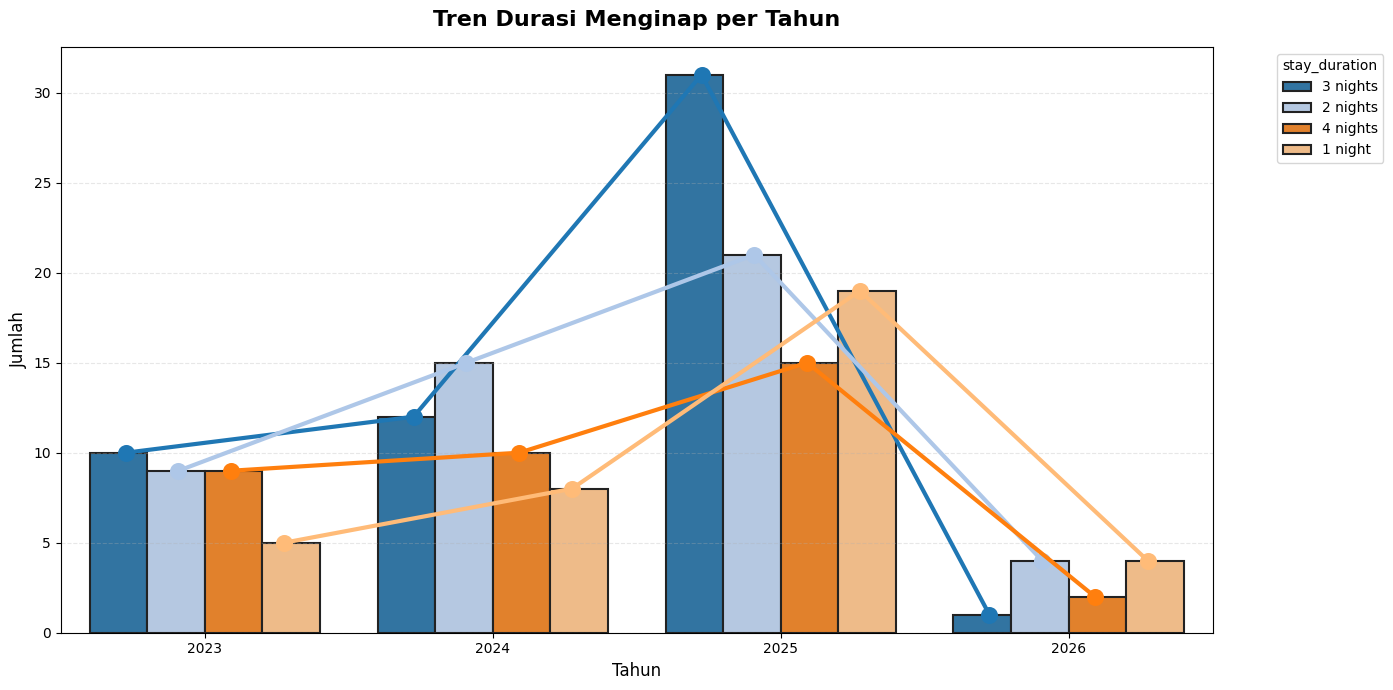

In [66]:
plot_multivariate_barplot(
    df=df,
    x_col="year",
    hue_col="stay_duration", # Ganti dengan nama kolom hasil regex tadi
    title="Tren Durasi Menginap per Tahun",
    x_label="Tahun",
    top_n_hue=4 # Hanya ambil 4 durasi terpopuler (misal 1, 2, 3, 4 malam)
)

    year    user_country  counts
0   2023       Australia      23
1   2023     New Zealand       4
2   2023          France       1
3   2023         Germany       0
4   2023  United Kingdom       0
5   2023   United States       2
6   2023       Indonesia       2
7   2023     Switzerland       1
8   2023     Netherlands       0
9   2023           Italy       1
10  2024       Australia      32
11  2024     New Zealand       3
12  2024          France       5
13  2024         Germany       3
14  2024  United Kingdom       5
15  2024   United States       3
16  2024       Indonesia       1
17  2024     Switzerland       0
18  2024     Netherlands       3
19  2024           Italy       0
20  2025       Australia      50
21  2025     New Zealand       6
22  2025          France       6
23  2025         Germany       7
24  2025  United Kingdom       4
25  2025   United States       4
26  2025       Indonesia       4
27  2025     Switzerland       6
28  2025     Netherlands       3
29  2025  

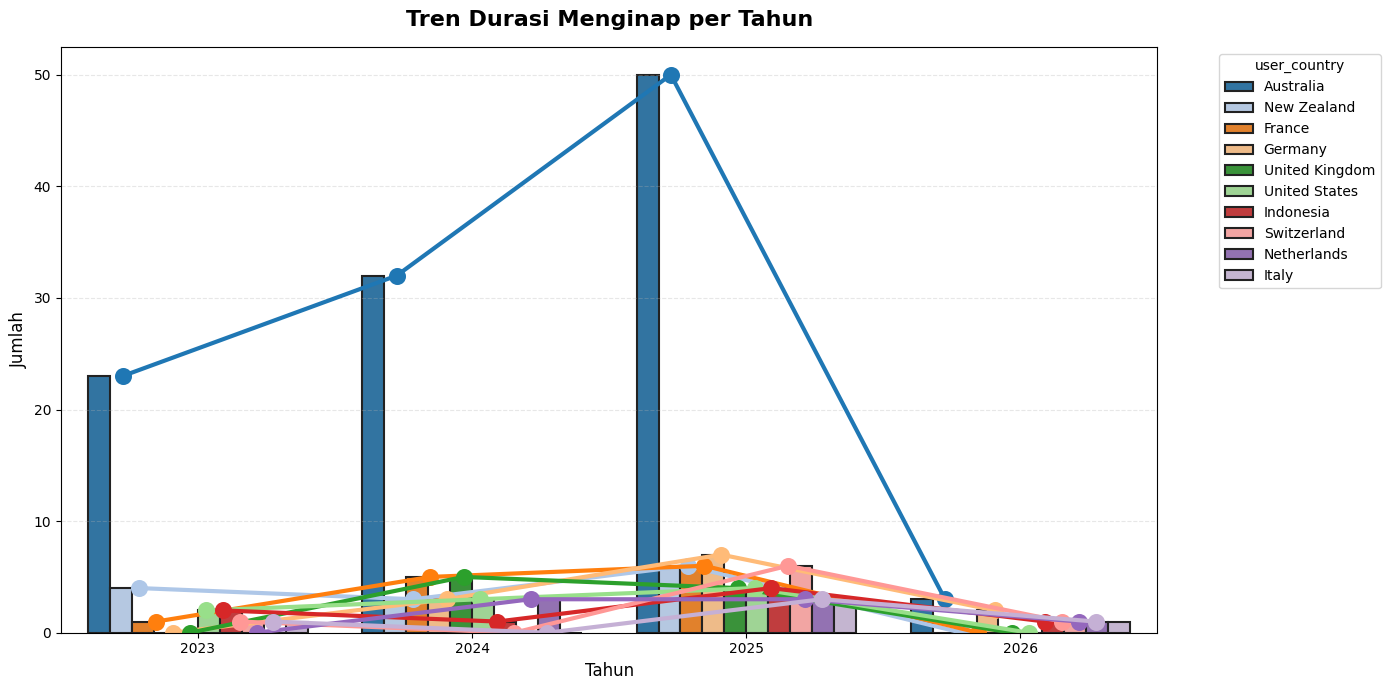

In [67]:
plot_multivariate_barplot(
    df=df,
    x_col="year",
    hue_col="user_country", # Ganti dengan nama kolom hasil regex tadi
    title="Tren Durasi Menginap per Tahun",
    x_label="Tahun",
    top_n_hue=10 # Hanya ambil 4 durasi terpopuler (misal 1, 2, 3, 4 malam)
)

    year    user_country  counts
0   2023     New Zealand       4
1   2023          France       1
2   2023         Germany       0
3   2023  United Kingdom       0
4   2023   United States       2
5   2023       Indonesia       2
6   2023     Switzerland       1
7   2023     Netherlands       0
8   2023           Italy       1
9   2023           Japan       0
10  2024     New Zealand       3
11  2024          France       5
12  2024         Germany       3
13  2024  United Kingdom       5
14  2024   United States       3
15  2024       Indonesia       1
16  2024     Switzerland       0
17  2024     Netherlands       3
18  2024           Italy       0
19  2024           Japan       0
20  2025     New Zealand       6
21  2025          France       6
22  2025         Germany       7
23  2025  United Kingdom       4
24  2025   United States       4
25  2025       Indonesia       4
26  2025     Switzerland       6
27  2025     Netherlands       3
28  2025           Italy       3
29  2025  

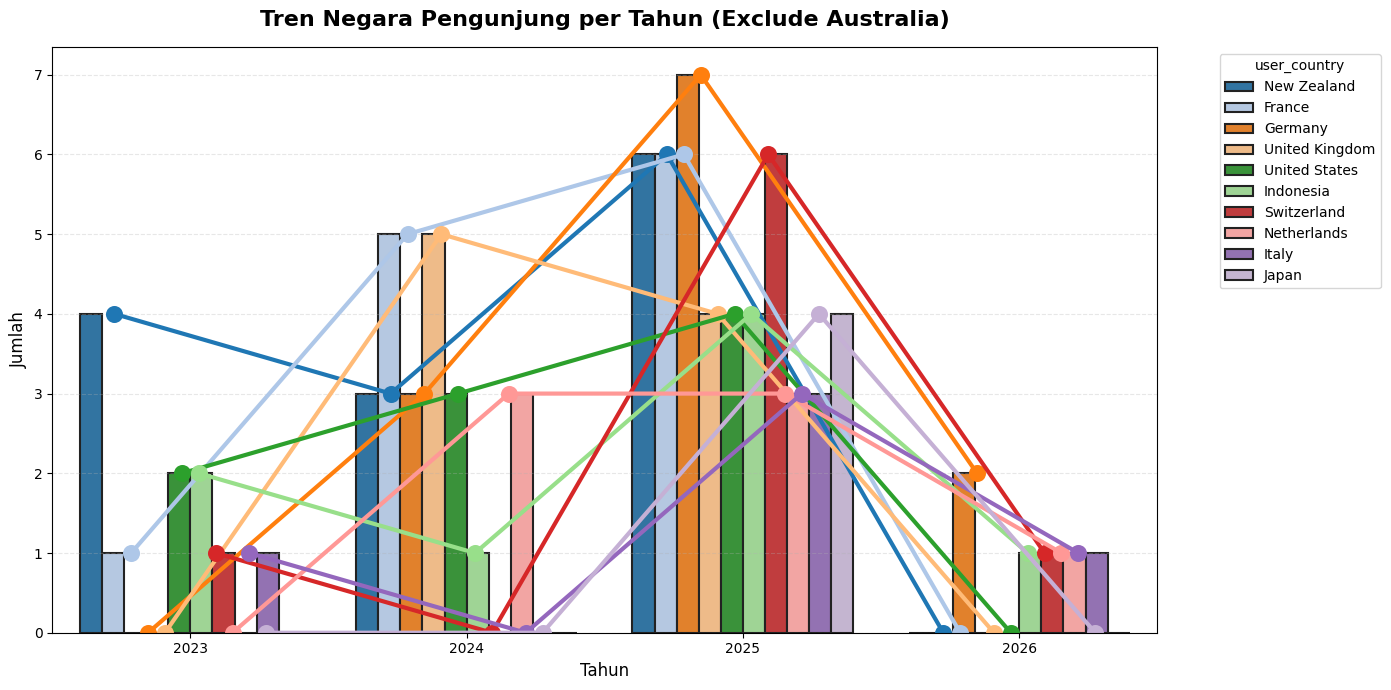

In [68]:
plot_multivariate_barplot(
    df=df[df['user_country'] != 'Australia'],
    x_col="year",
    hue_col="user_country",
    title="Tren Negara Pengunjung per Tahun (Exclude Australia)",
    x_label="Tahun",
    top_n_hue=10
)